# Move up

Exercises the **async** faro pipeline end-to-end on the Moench, modelled on the
random-stim experiment but with the **region-percentage** stimulator
(`StimPercentageOfCell`) from the demo notebook, which illuminates the top
*percentage* of each segmented cell.

- **Imaging:** red (`mScarlet3`, ERK-KTR reporter) + farred (`miRFP`, PIP).
- **Stim == ref channel:** `CyanStim` is used for both stimulation and the
  reference/optocheck readout.
- **Segmentation:** Cellpose 4 (channel 0). **Tracking:** motile.
- **Phases (single RTMSequence):** baseline → stim → baseline (recovery) → ref,
  via `stim_frames` for the stim block and `ref_frames=[-1]` for the final
  reference frame.
- **Timing:** 1 min interval, ~3 s per FOV.
- **Async run:** `run_experiment` returns a `RunHandle`; the
  `ExperimentStatusWidget` mirrors/steers it live; background DMD calibration.

> **Storage note:** this writes OME-Zarr to `path` below. The `init_stream`
> SMB fix (PR #12) is **not** on this `move-up` branch — if you hit
> `PermissionError [WinError 5]` at init on the `Z:` drive, either store
> locally or have the storage fix cherry-picked onto this branch.
>
> **Env:** run with the cellpose + tracking extras, e.g.
> `uv sync --extra cellpose --extra tracking` in this worktree.

In [2]:
import os
import time
import numpy as np
import pandas as pd

import napari
from napari_micromanager import MainWindow
import pymmcore_plus

from faro.microscope.pertzlab.moench import Moench
from faro.core.data_structures import (
    Channel,
    PowerChannel,
    RTMSequence,
    SegmentationMethod,
    combine,
    wait,
)
from faro.core.pipeline import ImageProcessingPipeline
from faro.core.controller import Controller
from faro.core.writers import OmeZarrWriter
import faro.core.utils as utils

from faro.segmentation.cellpose_v4 import CellposeV4
from faro.tracking.motile_tracker import TrackerMotile
from faro.feature_extraction.erk_ktr import FE_ErkKtr
from faro.stimulation.percentage_of_cell import StimUp

from faro.widgets import ExperimentStatusWidget

## Microscope + napari

In [3]:
mic = Moench(None)
mic.mmc.setChannelGroup("TTL_ERK")

In [4]:
# Open napari with the napari-micromanager widget bound to the scope's core.
# Use the MDA widget to pick the FOV positions for generate_fov_positions below.
viewer = napari.Viewer()
mm_wdg = MainWindow(viewer, mmcore=mic.mmc)
viewer.window.add_dock_widget(mm_wdg)

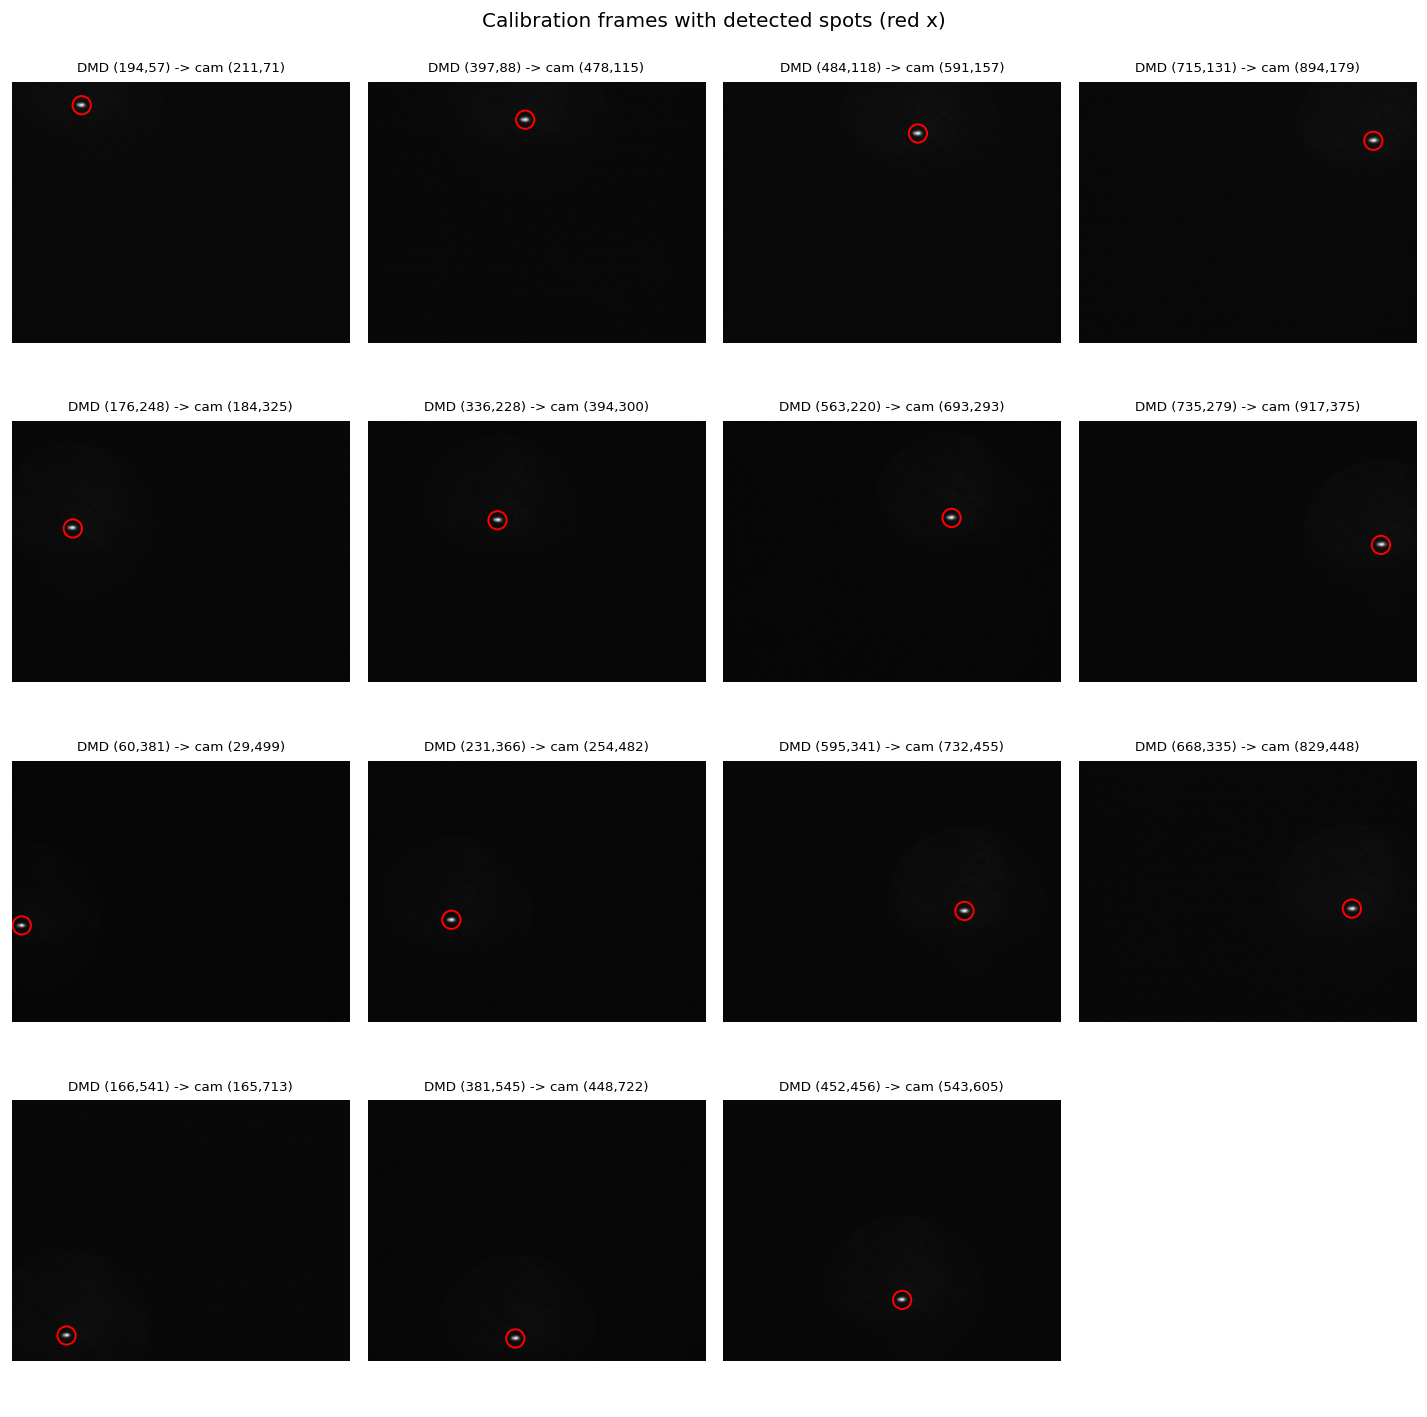

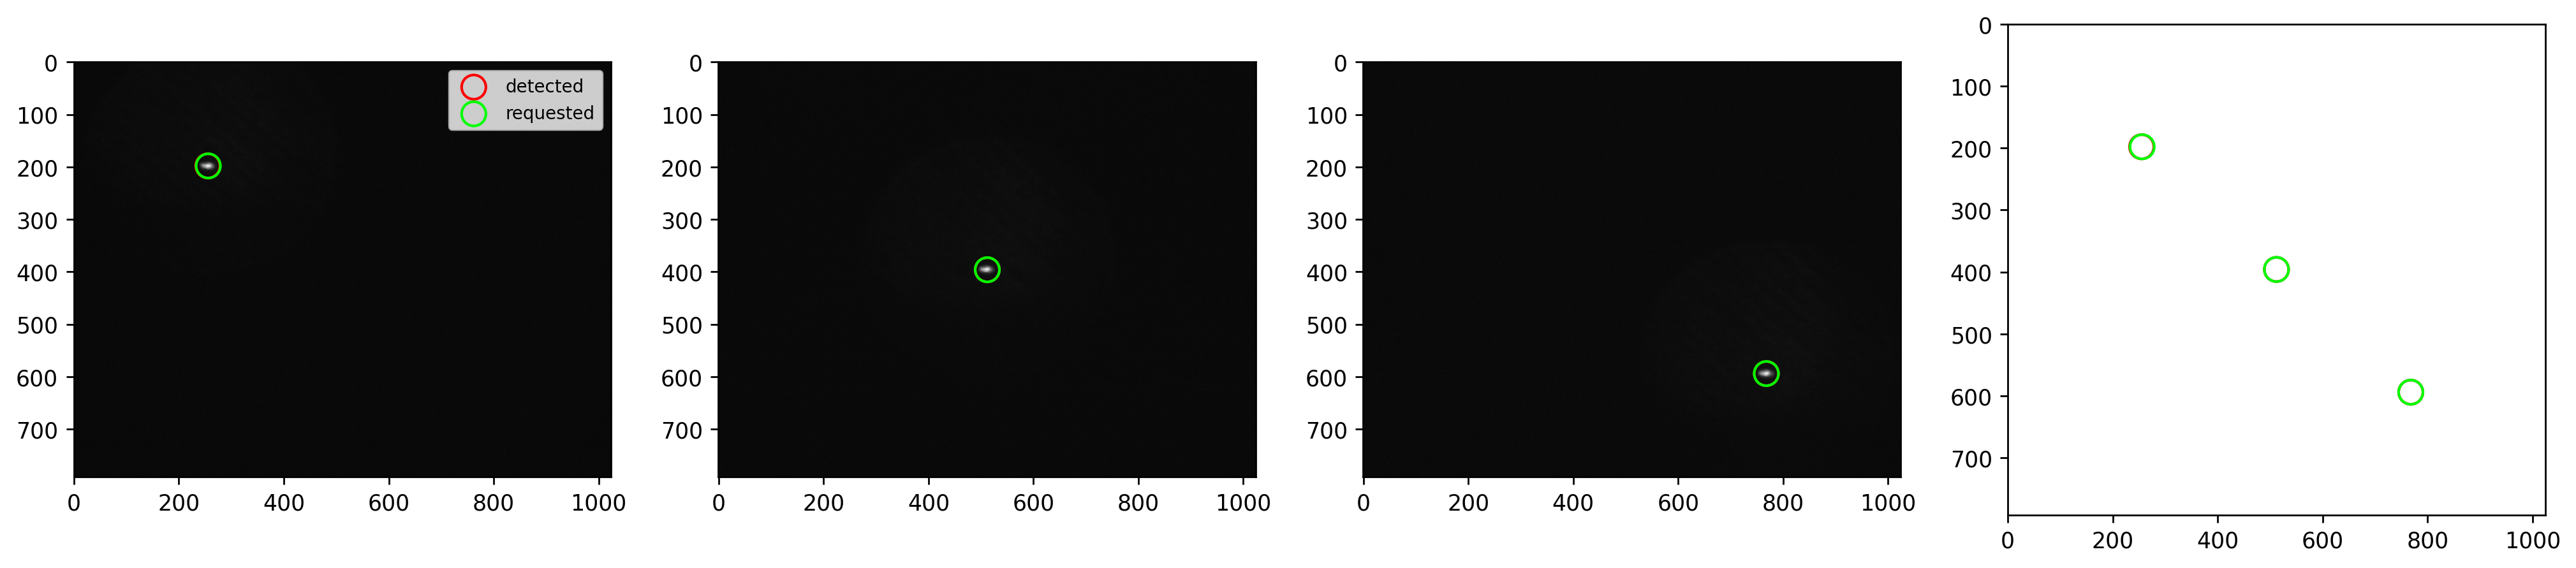

In [5]:
# DMD calibration runs on a background thread (background=True default), so
# napari keeps streaming the live preview while it calibrates.
mic.dmd.affine = None
pymmcore_plus.configure_logging(stderr_level="CRITICAL")
mic.calibrate_dmd(verbose=True, radius=4)
# Or reuse a saved calibration instead of recalibrating:
# mic.dmd.affine = np.load("affine.npy")

## Channels

In [6]:
# Stimulation channel -- ALSO the reference channel (ref == stim): the
# optogenetic-tool readout is acquired in the same channel that drives stim.
stim_channel = PowerChannel(config="CyanStim", exposure=200, group="TTL_ERK", power=25)

# Imaging channels -- order matters: channel 0 is the one cellpose segments.
imaging_channels = (
    PowerChannel(config="mScarlet3", exposure=250, group="TTL_ERK", power=20),    # red    (ERK-KTR reporter)
    PowerChannel(config="miRFP",     exposure=250, group="TTL_ERK", power=20),  # farred (PIP)
)

ref_channel = PowerChannel(config="mCitrine", exposure=200, group="TTL_ERK", power=50)

## Experiment config: baseline → stim → baseline → ref

In [9]:
# --- timing ----------------------------------------------------------------
INTERVAL_S     = 30      # 1 min between timepoints
TIME_PER_FOV_S = 5.0     # ~3 s to image one FOV (staggers per-FOV start times)

# --- phases ----------------------------------------------------------------
N_BASELINE = 120           # baseline imaging frames (pre-stim)
N_STIM     = 600           # stim frames (region-percentage stim fires)
N_RECOVERY = 120           # baseline imaging frames (post-stim recovery)
N_REF      = 1           # final reference-acquisition frame
N_FRAMES   = N_BASELINE + N_STIM + N_RECOVERY + N_REF

STIM_FRAMES = list(range(N_BASELINE, N_BASELINE + N_STIM))   # contiguous stim block
REF_FRAMES  = [-1]                                           # last frame = reference

# Fraction of each cell to stimulate (top region) -- read by StimPercentageOfCell
# from event metadata; default in the stimulator is 0.3 if omitted.
STIM_CELL_PERCENTAGE = 0.2

# --- storage ---------------------------------------------------------------
# See the storage note at the top re: SMB / PR #12.
base_path = r"C:\Users\lh21x018\Desktop\temp"
# base_path = r"Z:\lhinder\data\rtm_mm_data\exp_move_up_test"
experiment_name = "region_percentage_stim_Laurent2"
path = os.path.join(base_path, experiment_name)

## Pipeline: CellposeV4 + motile + region-percentage stim

In [10]:
segmentators = [
    SegmentationMethod(
        name="labels",
        segmentation_class=CellposeV4(),   # Cellpose 4
        use_channel=0,                      # segment the red (mScarlet3) channel
        save_tracked=True,
    )
]
stimulator = StimUp()          # stimulates the top % of each cell
feature_extractor = FE_ErkKtr("labels")      # per-cell features (feeds the tracker)
tracker = TrackerMotile(search_range=70)     # motile tracking

pipeline = ImageProcessingPipeline(
    storage_path=path,
    segmentators=segmentators,
    feature_extractor=feature_extractor,
    tracker=tracker,
    stimulator=stimulator,
)

writer = OmeZarrWriter(storage_path=path)
ctrl = Controller(mic, pipeline, writer=writer)

Directory C:\Users\lh21x018\Desktop\temp\region_percentage_stim_Laurent2\tracks created 


## Build the acquisition

In [ ]:
# Pick the FOV positions in the napari-mm MDA widget first, then run this cell.
fov_positions = utils.generate_fov_positions(mic, viewer=viewer)

phase = RTMSequence(
    time_plan={"interval": INTERVAL_S, "loops": N_FRAMES},
    stage_positions=fov_positions,
    channels=imaging_channels,
    stim_channels=(stim_channel,),
    stim_frames=STIM_FRAMES,
    ref_channels=(ref_channel,),    # ref == stim channel
    ref_frames=REF_FRAMES,
    rtm_metadata={
        "phase_name": "region_percentage_stim",
        "phase_id": 0,   # pipeline names tracks parquet from this -- required
        "stim_cell_percentage": STIM_CELL_PERCENTAGE,
        "treatment_name": "Top-percentage-of-cell optogenetic stimulation",
    },
)
initial_wait = wait(10800)

events = combine(initial_wait,phase, axis="t")
# offset_min_start_time staggers each FOV's scheduled start by its slot in the
# batch, keeping the per-FOV frame interval consistent and lag meaningful.
events = utils.apply_fov_batching(
    events, time_per_fov=TIME_PER_FOV_S, offset_min_start_time=True
)
ctrl.validate_events(events)

True

## Validate + dock the status widget

In [15]:
# Mirrors and steers the current run (state, event strip, FOV map, lag,
# pause/stop); re-binds automatically on each run_experiment.
status_wdg = ExperimentStatusWidget(ctrl)
viewer.window.add_dock_widget(status_wdg, name="Experiment status")

## Run (async)

In [19]:
time_before_exp = 3600

for _ in range(time_before_exp):
    time.sleep(1)
# Returns a RunHandle immediately and drives the MDA on a worker thread.
# Watch the status widget, or use handle.status() / handle.pause() /
# handle.resume() / handle.cancel(). stim_mode="current": stim fires after
# imaging frame t using frame t's segmentation mask.
handle = ctrl.run_experiment(events, stim_mode="previous")

In [17]:
handle.status()

RunStatus(state='done', current_event_index={'t': 1, 'p': 1}, current_fov=1, n_events_total=30276, n_events_consumed=8, n_events_acquired=6, n_frames_received=11, started_at=1575943.0011778, finished_at=1575966.0778873, last_frame_wallclock=1780064556.6035893, lag_ms=-2177.8565999120474, wait_remaining_s=None, pipeline_inflight=0, storage_queue_depth=0, background_errors=(), fatal_error=None)

## Finish + post-process

In [20]:
# Blocks until the run finishes, flushes the pipeline, and closes the zarr store.
ctrl.finish_experiment()

# Merge per-FOV tracks into a single exp_data.parquet for analysis.
utils.generate_exp_data_from_tracks(path)